In [5]:
import numpy as np

In [6]:
class Value:
    def __init__(self, value, children = (), op = '', label = '', grad = 0):
        
        self.value = value
        self._prev = children
        self._backward = lambda : None
        self.grad = grad
        self._op = op
        self.label = label

    def __repr__(self):
        
        return f'Value <data = {self.value}>'

    def __add__(self, other):

        if isinstance(other, Value):
            new_val = other.value

            out = Value(new_val + self.value, (self, other), '+')
            
            def _backward():
                self.grad += 1.0 * out.grad
                other.grad += 1.0 * out.grad 
            out._backward = _backward
            
        else:
            return NotImplemented
        
        return out

    def __mul__(self, other):
        
        if isinstance(other, Value):
            new_val = other.value

            out = Value(new_val * self.value, (self, other), '*')
            
            def _backward():
                self.grad += out.grad * other.value
                other.grad += out.grad * self.value
            out._backward = _backward
            
        else:
            return NotImplemented
        
        return out

    def tanh(self):
        x = self.value
        t = (np.exp(2*x) - 1) / (np.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += out.grad * (1.0 - t**2)
        out._backward = _backward
        
        return out

    def backward(self):
        
        topo = []
        visited = set()
        
        def dfs(node):
    
            if node in visited:
                return
    
            visited.add(node)
    
            for child in node._prev:
                dfs(child)
    
            topo.append(node)
    
        dfs(self)
    
        self.grad = 1

        for node in reversed(topo):
            node._backward()

In [3]:
#Graph visualizer
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{ %s | value %.4f | grad %.2f }" % (n.label, n.value, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

In [4]:
'''
a = Value(1, label = 'a')
b = Value(2, label = 'b')
c = a * b; c.label = 'c'

d = Value(3, label = 'd')
f = c + d; f.label = 'f'

g = Value(4, label = 'g')
L = g * f; L.label = 'L'

L.grad = 1 # dL/dL

"""
 L = f*g
 dL / df = g
 dL / dg = f
"""
g.grad = f.value
f.grad = g.value

"""
 dL / dc = (dL / df) * (df / dc)
         = g * 1 = g

 dL / dd = (dL / df) * (df / dd)
         = g * 1 = g
"""
c.grad = g.value
d.grad = g.value

"""
 dL / da = (dL / df) * (df / dc) * (dc / da)
         = g * 1 * b
         
 dL / db = (dL / df) * (df / dc) * (dc / db)
         = g * 1 * a
"""
a.grad = g.value * b.value
b.grad = g.value * a.value

draw_dot(L)
'''

'\na = Value(1, label = \'a\')\nb = Value(2, label = \'b\')\nc = a * b; c.label = \'c\'\n\nd = Value(3, label = \'d\')\nf = c + d; f.label = \'f\'\n\ng = Value(4, label = \'g\')\nL = g * f; L.label = \'L\'\n\nL.grad = 1 # dL/dL\n\n"""\n L = f*g\n dL / df = g\n dL / dg = f\n"""\ng.grad = f.value\nf.grad = g.value\n\n"""\n dL / dc = (dL / df) * (df / dc)\n         = g * 1 = g\n\n dL / dd = (dL / df) * (df / dd)\n         = g * 1 = g\n"""\nc.grad = g.value\nd.grad = g.value\n\n"""\n dL / da = (dL / df) * (df / dc) * (dc / da)\n         = g * 1 * b\n\n dL / db = (dL / df) * (df / dc) * (dc / db)\n         = g * 1 * a\n"""\na.grad = g.value * b.value\nb.grad = g.value * a.value\n\ndraw_dot(L)\n'

In [5]:
#inputs
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')

#weights
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')

#product of inputs, weights
x1w1 = x1*w1; x1w1.label = 'x1 * w1'
x2w2 = x2*w2; x2w2.label = 'x2 * w2'

#sum of product of weights
xw = x1w1 + x2w2; xw.label = 'x1*w1 + x2*w2'

#adding bias
bias = Value(6.8814, label = 'b')
xwb = xw + bias; xwb.label = 'x1*w1 + x2*w2 + bias'

#activation function (tanh)
out = xwb.tanh(); out.label = 'out'

In [6]:
out.backward()

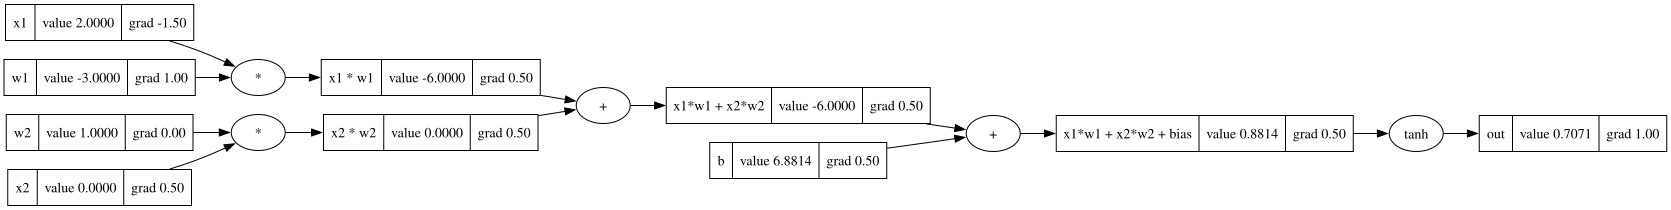

In [7]:
draw_dot(out)

In [9]:
import random

In [38]:
class Neuron:

    def __init__(self, n):
        self.w = [Value(random.uniform(-1,1)) for _ in range(n)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        aggr = sum((xi*wi for xi, wi in zip(x, self.w)), self.b)
        activated = aggr.tanh()
        return aggr

    def __repr__(self):
        return f'Neuron<Weights: {self.w}, Bias: {self.b}>'

In [43]:
n = Neuron(2)
n

Neuron<Weights: [Value <data = -0.15649363761140322>, Value <data = 0.7686668821106226>], Bias: Value <data = -0.7776092483476116>>

In [44]:
x = [Value(i) for i in range(1,3)]
x

[Value <data = 1>, Value <data = 2>]

In [45]:
pred = n(x)
pred

Value <data = 0.6032308782622304>